# Descomposición del Desarrollo (Development Accounting)

## Modelo

$$y = A \cdot \underbrace{\left(\frac{K}{Y}\right)^{\alpha/(1-\alpha)}}_{\text{factor capital}} \cdot h \cdot e$$

donde:
- $y = \text{rgdpo}/\text{emp}$ — producto por trabajador
- $K/Y = \text{cn}/\text{rgdpo}$
- $\alpha = 1/3$
- $h = \text{hc}$ — capital humano
- $e = (\gamma\,(1-\alpha)\,y)^{\gamma}$ — factor de esfuerzo/utilización, con $\gamma \in \{0, 0.25, 0.5, 0.75, 1\}$
- $A$ — TFP calculada por residuo

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import openpyxl as op
import warnings
warnings.filterwarnings('ignore')

## 1. Carga de datos

In [2]:
df = pd.read_excel('Datos_jabb.xlsx')
print(f'Observaciones: {len(df)} países')
df.head()

Observaciones: 141 países


,country,rgdpo,pop,emp,hc,cn,ln(A/A_us),ln(h/h_us)
0,Albania,36103.042969,2.880917,1.075898,2.964992,2.239714e+05,-1.428059,-0.234706
1,Algeria,507487.562500,43.053054,11.273454,2.383965,2.290438e+06,-0.757092,-0.452815
2,Angola,227855.718750,31.825295,16.644962,1.481984,1.299232e+06,-1.589020,-0.928198
3,Argentina,977420.562500,44.780677,20.643215,3.096804,3.183182e+06,-0.805036,-0.191209
4,Armenia,43582.574219,2.957731,0.966091,3.135995,9.324618e+04,-0.655920,-0.178634


## 2. Cálculo de variables base

In [3]:
alpha = 1/3
gammas = [0, 0.25, 0.5, 0.75, 0.90]

# Producto por trabajador
df['y'] = df['rgdpo'] / df['emp']

# Razón capital-producto
df['KY'] = df['cn'] / df['rgdpo']

# Factor capital: (K/Y)^{alpha/(1-alpha)}
df['factor_capital'] = df['KY'] ** (alpha / (1 - alpha))

# Capital humano
df['h'] = df['hc']

print('Variables base calculadas:')
df[['country', 'y', 'KY', 'factor_capital', 'h']].head(5)

Variables base calculadas:


,country,y,KY,factor_capital,h
0,Albania,33556.204444,6.203670,2.490717,2.964992
1,Algeria,45016.157022,4.513288,2.124450,2.383965
2,Angola,13689.170002,5.701992,2.387884,1.481984
3,Argentina,47348.271769,3.256717,1.804638,3.096804
4,Armenia,45112.287815,2.139529,1.462713,3.135995


## 3. Descomposición para cada $\gamma$

Para $\gamma = 0$, entonces $e = 1$.

In [8]:
results = {}

for gamma in gammas:
    res = df[['country', 'y', 'factor_capital', 'h']].copy()
    
    if gamma == 0:
        # e = (0*(1-alpha)*y)^0 = 1 por convención
        res['e'] = 1.0
    else:
        # e = (gamma * (1-alpha) * y)^gamma
        res['e'] = (gamma * (1 - alpha) * df['y']) ** gamma
    
    # A por residuo
    res['A'] = df['y'] / (res['factor_capital'] * res['h'] * res['e'])
    
    results[gamma] = res
    print(f'\n=== gamma = {gamma} ===')
    print(res[['country', 'y', 'factor_capital', 'h', 'e', 'A']].head(3).to_string(index=False))


=== gamma = 0 ===
country            y  factor_capital        h   e           A
Albania 33556.204444        2.490717 2.964992 1.0 4543.860032
Algeria 45016.157022        2.124450 2.383965 1.0 8888.366033
 Angola 13689.170002        2.387884 1.481984 1.0 3868.300352

=== gamma = 0.25 ===
country            y  factor_capital        h        e          A
Albania 33556.204444        2.490717 2.964992 8.647795 525.435667
Algeria 45016.157022        2.124450 2.383965 9.306884 955.031375
 Angola 13689.170002        2.387884 1.481984 6.911248 559.710843

=== gamma = 0.5 ===
country            y  factor_capital        h          e         A
Albania 33556.204444        2.490717 2.964992 105.761058 42.963451
Algeria 45016.157022        2.124450 2.383965 122.496472 72.560180
 Angola 13689.170002        2.387884 1.481984  67.550401 57.265394

=== gamma = 0.75 ===
country            y  factor_capital        h           e        A
Albania 33556.204444        2.490717 2.964992 1474.202445 3.082250
Al

##############################

**NO CORRER ESTO**

**Corrección:** el $e$ definido antes está mal. No debería estar elevado a nada. Este, cuando lo determinas con $z_c$ te quedaba $$e = \gamma (1- \alpha) y_c$$

In [ ]:
results = {}

for gamma in gammas:
    res = df[['country', 'y', 'factor_capital', 'h']].copy()
    
    if gamma == 0:
        # e = (0*(1-alpha)*y)^0 = 1 por convención
        res['e'] = 1.0
    else:
        # e = (gamma * (1-alpha) * y)^gamma
        res['e'] = (gamma * (1 - alpha) * df['y'])   # no debería tener elevado nada
    
    # A por residuo
    res['A'] = df['y'] / (res['factor_capital'] * res['h'] * res['e'])
    
    results[gamma] = res
    print(f'\n=== gamma = {gamma} ===')
    print(res[['country', 'y', 'factor_capital', 'h', 'e', 'A']].to_string(index=False))

**Corrección final y por qué no cierra todo en 1 abajo:** h de la PWT no incluye el e.
Cuando el $\gamma$ es distinto de cero al A lo estas dividiendo por algo incorrecto, ya que ese h debería incluir el $s(1-s)$

**¡NO CORRER ESTO!**   **Me quedé finalmente con la duda. El problema es que no tengo s en la data y no creo que vaya por ahí la cosa**

In [ ]:
results = {}
for gamma in gammas:
    res = df[['country', 'y', 'factor_capital', 'h', 's']].copy()
    # h aquí es h_pwt = s^eta, viene de los datos
    
    if gamma == 0:
        res['e'] = 1.0
        res['h_ms'] = res['h'] * (1 - res['s'])  # s^eta * (1-s)
    else:
        res['e'] = (gamma * (1 - alpha) * df['y']) ** (1 / (1 - gamma))
        res['h_ms'] = res['h'] * (res['e'] ** gamma) * (1 - res['s'])  # s^eta * e^gamma * (1-s)
    
    # A por residuo usando h completo
    res['A'] = df['y'] / (res['factor_capital'] * res['h_ms'])
    
    results[gamma] = res

################################

## 7. Descomposición de covarianza

Como $\ln y = \ln A + \ln(\text{factor capital}) + \ln h + \ln e$, se cumple:

$$\text{Var}(\ln y) = \text{Cov}(\ln y, \ln A) + \text{Cov}(\ln y, \ln\text{fc}) + \text{Cov}(\ln y, \ln h) + \text{Cov}(\ln y, \ln e)$$

La **participación** de cada componente es:

$$\theta_X = \frac{\text{Cov}(\ln y,\, \ln X)}{\text{Var}(\ln y)}$$

y por construcción $\theta_A + \theta_{\text{fc}} + \theta_h + \theta_e = 1$.

In [9]:
cov_rows = []

for gamma in gammas:
    res = results[gamma].copy()

    ln_y  = np.log(res['y'])
    ln_fc = np.log(res['factor_capital'])
    ln_h  = np.log(res['h'])
    ln_e  = np.log(res['e']) if gamma > 0 else pd.Series(np.zeros(len(res)), index=res.index)
    ln_A  = np.log(res['A'])

    n     = len(ln_y)
    var_y = ln_y.var(ddof=0)

    # Covarianzas con ddof=0
    cov_A  = ((ln_y - ln_y.mean()) * (ln_A  - ln_A.mean())).mean()
    cov_fc = ((ln_y - ln_y.mean()) * (ln_fc - ln_fc.mean())).mean()
    cov_h  = ((ln_y - ln_y.mean()) * (ln_h  - ln_h.mean())).mean()
    cov_e  = ((ln_y - ln_y.mean()) * (ln_e  - ln_e.mean())).mean()

    cov_rows.append({
        'gamma'              : gamma,
        'Var(ln y)'          : var_y,
        'Cov(ln y, ln A)'    : cov_A,
        'Cov(ln y, ln fc)'   : cov_fc,
        'Cov(ln y, ln h)'    : cov_h,
        'Cov(ln y, ln e)'    : cov_e,
        'θ_A'   : cov_A  / var_y,
        'θ_fc'  : cov_fc / var_y,
        'θ_h'   : cov_h  / var_y,
        'θ_e'   : cov_e  / var_y,
    })

cov_df = pd.DataFrame(cov_rows).set_index('gamma')

print('=== Covarianzas brutas ===')
display(cov_df[['Var(ln y)', 'Cov(ln y, ln A)', 'Cov(ln y, ln fc)', 'Cov(ln y, ln h)', 'Cov(ln y, ln e)']].round(4))

print('\n=== Participaciones θ (suman 1 por construcción) ===')
display(cov_df[['θ_A', 'θ_fc', 'θ_h', 'θ_e']].round(4))

# Verificación
print('\nSuma de θ por gamma (debe ser 1):')
print(cov_df[['θ_A','θ_fc','θ_h','θ_e']].sum(axis=1).round(10))

=== Covarianzas brutas ===


,Var(ln y),"Cov(ln y, ln A)","Cov(ln y, ln fc)","Cov(ln y, ln h)","Cov(ln y, ln e)"
gamma,,,,,
0.00,1.1871,0.8374,0.0983,0.2514,0.0000
0.25,1.1871,0.5407,0.0983,0.2514,0.2968
0.50,1.1871,0.2439,0.0983,0.2514,0.5936
0.75,1.1871,-0.0529,0.0983,0.2514,0.8903
0.90,1.1871,-0.2310,0.0983,0.2514,1.0684



=== Participaciones θ (suman 1 por construcción) ===


,θ_A,θ_fc,θ_h,θ_e
gamma,,,,
0.00,0.7054,0.0828,0.2118,0.00
0.25,0.4554,0.0828,0.2118,0.25
0.50,0.2054,0.0828,0.2118,0.50
0.75,-0.0446,0.0828,0.2118,0.75
0.90,-0.1946,0.0828,0.2118,0.90



Suma de θ por gamma (debe ser 1):
gamma
0.00    1.0
0.25    1.0
0.50    1.0
0.75    1.0
0.90    1.0
dtype: float64


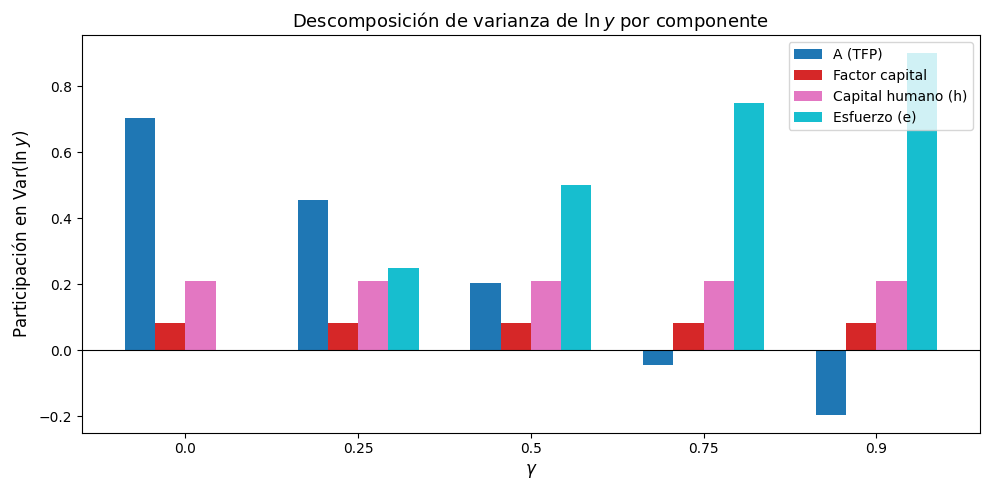

In [10]:
# Gráfico de participaciones θ por γ
theta_df = cov_df[['θ_A', 'θ_fc', 'θ_h', 'θ_e']].copy()
theta_df.columns = ['A (TFP)', 'Factor capital', 'Capital humano (h)', 'Esfuerzo (e)']

ax = theta_df.plot(kind='bar', figsize=(10, 5), colormap='tab10', width=0.7)
ax.axhline(0, color='black', linewidth=0.8)
ax.set_xlabel('$\\gamma$', fontsize=12)
ax.set_ylabel('Participación en $\\mathrm{Var}(\\ln y)$', fontsize=12)
ax.set_title('Descomposición de varianza de $\\ln y$ por componente', fontsize=13)
ax.legend(loc='upper right')
ax.tick_params(axis='x', rotation=0)
plt.tight_layout()

plt.savefig('descomposicion_covarianza.pdf', bbox_inches='tight')
plt.show()

## Ejercicio 2. Frontera tecnológica

Tenemos (consigna)

$$A_c = \hat{A}_c \left(\frac{h_c}{h_{us}}\right)^\gamma A_{us}$$

Encontrando fácilmente nuestro $\hat{A}_c$ o "TFP purificado" de nuestra distancia de la frontera tecnológica (US)

$$\hat{A}_c = \frac{A_c}{A_{us}} \left(\frac{h_{us}}{h_c}\right)^\gamma$$

Calculemos entonces las nuevas columnas "relativas" en la data.


In [11]:
us_name = 'United States'  # cambiá si es distinto en tus datos

results_p2 = {}

for gamma in gammas:
    res = results[gamma].copy()
    
    # ── Paso 1: calcular A_hat_c ──────────────────────────────────────────
    A_us = res.loc[res['country'] == us_name, 'A'].values[0]
    h_us = res.loc[res['country'] == us_name, 'h'].values[0]
    
    # A_c = A_hat_c * (h_c / h_us)^gamma * A_us
    # => A_hat_c = (A_c / A_us) * (h_us / h_c)^gamma
    res['A_hat'] = (res['A'] / A_us) * (h_us / res['h']) ** gamma
    
    # ── Paso 2: expresar todo relativo a EEUU ────────────────────────────
    y_us  = res.loc[res['country'] == us_name, 'y'].values[0]
    fc_us = res.loc[res['country'] == us_name, 'factor_capital'].values[0]
    A_hat_us = res.loc[res['country'] == us_name, 'A_hat'].values[0]

    res['y_rel']    = res['y'] / y_us                        # y_c / y_us
    res['A_hat_rel'] = res['A_hat'] / A_hat_us               # A_hat_c / A_hat_us
    res['fc_rel']   = res['factor_capital'] / fc_us          # factor capital relativo
    res['h_rel']    = (res['h'] / h_us) ** (1 + gamma)       # (h_c/h_us)^(1+gamma)
    
    us_row = res[res['country'] == us_name][['y_rel', 'A_hat_rel', 'fc_rel', 'h_rel']]
    print(f'\n=== gamma = {gamma} === verificación US (todo debe ser 1) ===')
    print(us_row.to_string(index=False))

    results_p2[gamma] = res
    
    print(f'\n=== gamma = {gamma} ===')
    print(res[['country', 'y_rel', 'A_hat_rel', 'fc_rel', 'h_rel']].to_string(index=False))


=== gamma = 0 === verificación US (todo debe ser 1) ===
 y_rel  A_hat_rel  fc_rel  h_rel
   1.0        1.0     1.0    1.0

=== gamma = 0 ===
                         country    y_rel  A_hat_rel   fc_rel    h_rel
                         Albania 0.257913   0.239774 1.360199 0.790803
                         Algeria 0.345994   0.469028 1.160178 0.635836
                          Angola 0.105215   0.204126 1.304042 0.395265
                       Argentina 0.363919   0.447072 0.985526 0.825960
                         Armenia 0.346733   0.518964 0.798798 0.836412
                       Australia 0.815421   0.760673 1.132274 0.946744
                         Austria 0.806905   0.698296 1.281405 0.901771
                         Bahrain 0.796621   1.065745 1.257027 0.594640
                      Bangladesh 0.089073   0.153366 1.036049 0.560576
                        Barbados 0.203784   0.170195 1.577372 0.759086
                         Belgium 0.807992   0.722167 1.332132 0.839890
      

# Descomposición de la varianza

Igual que siempre solo que ahora en términos relativos de EEUU. Esto debería quedarnos de la siguiente manera: 

$$\frac{y_c}{y_{us}} = \frac{\hat{A}_c}{A_{us}} \cdot \left(\frac{K_c/Y_c}{K_{us}/Y_{us}}\right)^{\frac{\alpha}{1-\alpha}} \cdot \left(\frac{h_c}{h_{us}}\right)^{1+\gamma}$$

$$1 = \frac{\mathrm{Cov}(\ln y_c/y_{us},\ \ln \hat{A}_c/A_{us})}{\mathrm{Var}(\ln y_c/y_{us})} + \frac{\mathrm{Cov}(\ln y_c/y_{us},\ \ln (K_c/Y_c)/(K_{us}/Y_{us}))}{\mathrm{Var}(\ln y_c/y_{us})} + \frac{\mathrm{Cov}(\ln y_c/y_{us},\ (1+\gamma)\ln h_c/h_{us})}{\mathrm{Var}(\ln y_c/y_{us})}$$

Procedemos a realizar la descomposición de la varianza en la data

In [ ]:
cov_results_p2 = []

for gamma in gammas:
    res = results_p2[gamma].copy()
    
    # Logs
    ln_y   = np.log(res['y_rel'])
    ln_A   = np.log(res['A_hat_rel'])
    ln_fc  = np.log(res['fc_rel'])
    ln_h   = np.log(res['h_rel'])      # ya tiene el (1+gamma) incorporado
    
    var_y  = np.var(ln_y, ddof=1)
    
    # Descomposición en covarianzas
    theta_A  = np.cov(ln_y, ln_A,  ddof=1)[0,1] / var_y
    theta_fc = np.cov(ln_y, ln_fc, ddof=1)[0,1] / var_y
    theta_h  = np.cov(ln_y, ln_h,  ddof=1)[0,1] / var_y
    
    cov_results_p2.append({
        'gamma'   : gamma,
        'θ_A_hat' : theta_A,
        'θ_fc'    : theta_fc,
        'θ_h_rel' : theta_h,
        'suma'    : theta_A + theta_fc + theta_h   # check: debe dar ~1
    })

cov_df_p2 = pd.DataFrame(cov_results_p2).set_index('gamma')
print(cov_df_p2.round(4))

       θ_A_hat    θ_fc  θ_h_rel  suma
gamma                                
0.00    0.7054  0.0828   0.2118  1.00
0.25    0.4025  0.0828   0.2647  0.75
0.50    0.0996  0.0828   0.3177  0.50
0.75   -0.2034  0.0828   0.3706  0.25
0.90   -0.3851  0.0828   0.4024  0.10


## Correción de la descomposición de varianzas relativas a US porque no suman uno y es una identidad contable que sí debería dar

- check de que el fc_us no esté elevado también al $\frac{\alpha}{1-\alpha}$.
    Sí lo esta: cuando defines factor_capital lo hiciste para todos los países incluído US



In [12]:
us_name = 'United States'  # cambiá si es distinto en tus datos

results_p2 = {}

for gamma in gammas:
    res = results[gamma].copy()
    
    # ── Paso 1: calcular A_hat_c ──────────────────────────────────────────
    A_us = res.loc[res['country'] == us_name, 'A'].values[0]
    h_us = res.loc[res['country'] == us_name, 'h'].values[0]
    
    # A_c = A_hat_c * (h_c / h_us)^gamma * A_us
    # => A_hat_c = (A_c / A_us) * (h_us / h_c)^gamma
    res['A_hat'] = (res['A'] / A_us) * (h_us / res['h']) ** gamma
    
    # ── Paso 2: expresar todo relativo a EEUU ────────────────────────────
    y_us  = res.loc[res['country'] == us_name, 'y'].values[0]
    fc_us = res.loc[res['country'] == us_name, 'factor_capital'].values[0]
    A_hat_us = res.loc[res['country'] == us_name, 'A_hat'].values[0]

    res['y_rel']    = res['y'] / y_us                        # y_c / y_us
    res['A_hat_rel'] = res['A_hat'] / A_hat_us               # A_hat_c / A_hat_us
    res['fc_rel']   = res['factor_capital'] / fc_us          # factor capital relativo
    res['h_rel']    = (res['h'] / h_us) ** (1 + gamma)       # (h_c/h_us)^(1+gamma)
    
    us_row = res[res['country'] == us_name][['y_rel', 'A_hat_rel', 'fc_rel', 'h_rel']]
    print(f'\n=== gamma = {gamma} === verificación US (todo debe ser 1) ===')
    print(us_row.to_string(index=False))

    results_p2[gamma] = res
    
    print(f'\n=== gamma = {gamma} ===')
    print(res[['country', 'y_rel', 'fc_rel', 'A_hat_rel', 'h_rel']].head(3).to_string(index=False))



=== gamma = 0 === verificación US (todo debe ser 1) ===
 y_rel  A_hat_rel  fc_rel  h_rel
   1.0        1.0     1.0    1.0

=== gamma = 0 ===
country    y_rel   fc_rel  A_hat_rel    h_rel
Albania 0.257913 1.360199   0.239774 0.790803
Algeria 0.345994 1.160178   0.469028 0.635836
 Angola 0.105215 1.304042   0.204126 0.395265

=== gamma = 0.25 === verificación US (todo debe ser 1) ===
 y_rel  A_hat_rel  fc_rel  h_rel
   1.0        1.0     1.0    1.0

=== gamma = 0.25 ===
country    y_rel   fc_rel  A_hat_rel    h_rel
Albania 0.257913 1.360199   0.356793 0.745737
Algeria 0.345994 1.160178   0.684850 0.567781
 Angola 0.105215 1.304042   0.452018 0.313409

=== gamma = 0.5 === verificación US (todo debe ser 1) ===
 y_rel  A_hat_rel  fc_rel  h_rel
   1.0        1.0     1.0    1.0

=== gamma = 0.5 ===
country    y_rel   fc_rel  A_hat_rel    h_rel
Albania 0.257913 1.360199   0.530923 0.703239
Algeria 0.345994 1.160178   0.999982 0.507011
 Angola 0.105215 1.304042   1.000954 0.248504

=== gamma =

In [13]:
cov_results_p2 = []

for gamma in gammas:
    res = results_p2[gamma].copy()
    
    # Logs
    ln_y   = np.log(res['y_rel'])
    ln_A   = np.log(res['A_hat_rel'])
    ln_fc  = np.log(res['fc_rel'])
    ln_h   = np.log(res['h_rel'])      # ya tiene el (1+gamma) incorporado
    
    var_y  = np.var(ln_y, ddof=1)
    
    # Descomposición en covarianzas
    theta_A  = np.cov(ln_y, ln_A,  ddof=1)[0,1] / var_y
    theta_fc = np.cov(ln_y, ln_fc, ddof=1)[0,1] / var_y
    theta_h  = np.cov(ln_y, ln_h,  ddof=1)[0,1] / var_y
    
    cov_results_p2.append({
        'gamma'   : gamma,
        'θ_A_hat' : theta_A,
        'θ_fc'    : theta_fc,
        'θ_h_rel' : theta_h,
        'suma'    : theta_A + theta_fc + theta_h   # check: debe dar ~1
    })

cov_df_p2 = pd.DataFrame(cov_results_p2).set_index('gamma')
print(cov_df_p2.round(4))

       θ_A_hat    θ_fc  θ_h_rel  suma
gamma                                
0.00    0.7054  0.0828   0.2118  1.00
0.25    0.4025  0.0828   0.2647  0.75
0.50    0.0996  0.0828   0.3177  0.50
0.75   -0.2034  0.0828   0.3706  0.25
0.90   -0.3851  0.0828   0.4024  0.10


In [14]:
# Esto debería dar cero para todos los países
discrepancia = ln_y - ln_A - ln_fc - ln_h
print(discrepancia.describe())

count    141.000000
mean      -1.323878
std        0.984087
min       -3.842255
25%       -2.024824
50%       -1.118378
75%       -0.532776
max        0.479515
dtype: float64


############### Corrección finalizada #################

Veamos cómo se ve esta descomposición en un gráfico para distintos valores de $\gamma$ y comparemos con el primer $A_c$ encontrado

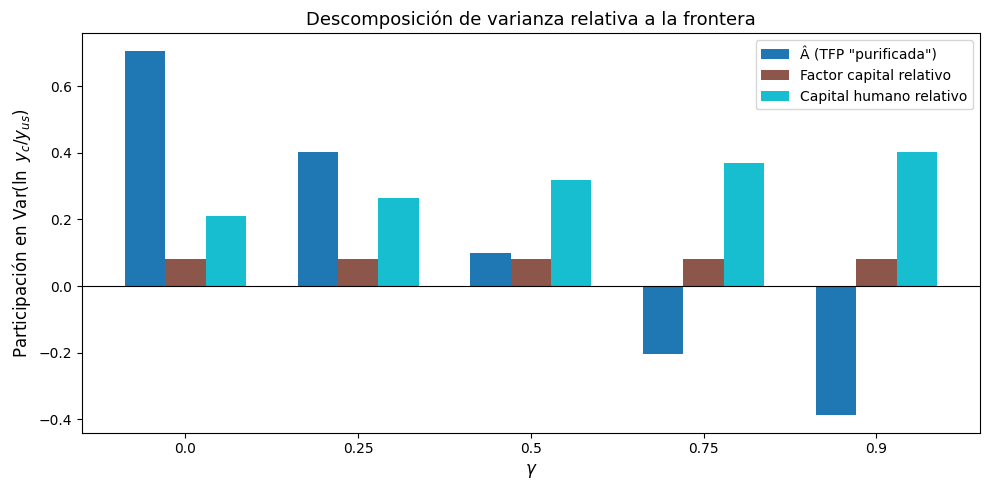

Guardado en: C:\Users\Juan\Desktop\descomposicion_relativa.pdf


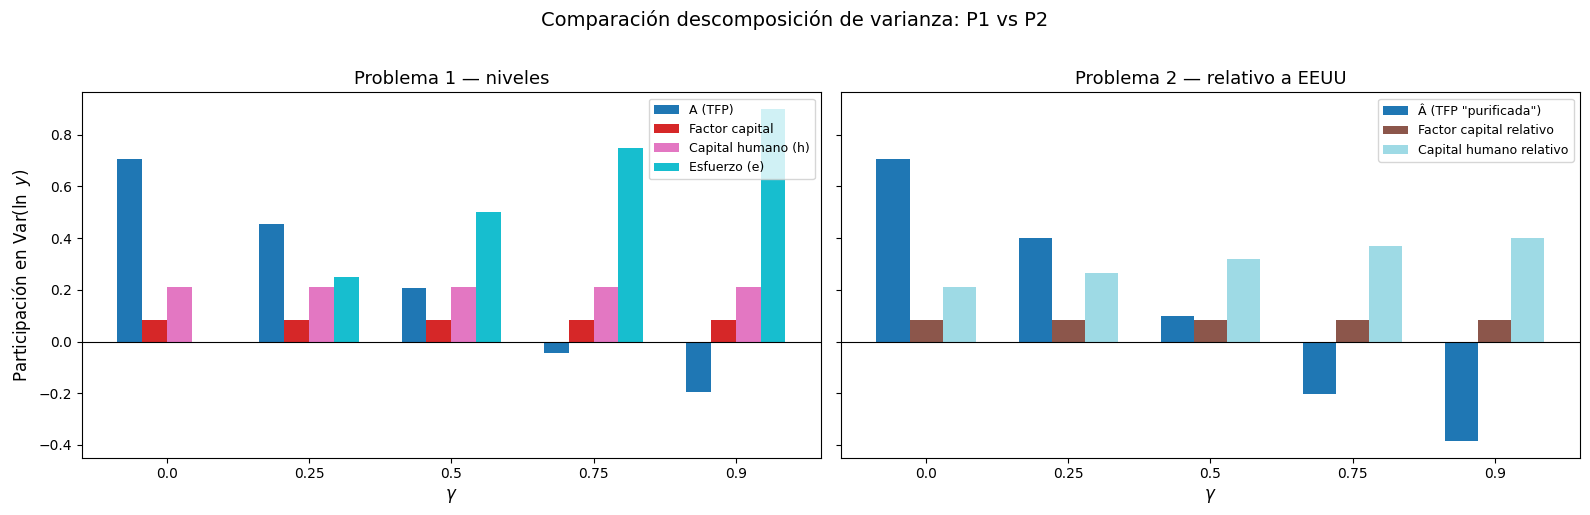

Guardado en: C:\Users\Juan\Desktop\comparacion_p1_p2.pdf


In [15]:
import matplotlib.pyplot as plt
import os

# ── Gráfico 1: descomposición relativa a la frontera ─────────────────────────
fig, ax = plt.subplots(figsize=(10, 5))

cov_df_p2[['θ_A_hat', 'θ_fc', 'θ_h_rel']].rename(columns={
    'θ_A_hat' : 'Â (TFP "purificada")',
    'θ_fc'    : 'Factor capital relativo',
    'θ_h_rel' : 'Capital humano relativo'
}).plot(kind='bar', ax=ax, colormap='tab10', width=0.7)

ax.axhline(0, color='black', linewidth=0.8)
ax.set_xlabel('$\\gamma$', fontsize=12)
ax.set_ylabel('Participación en $\\mathrm{Var}(\\ln\\ y_c/y_{us})$', fontsize=12)
ax.set_title('Descomposición de varianza relativa a la frontera', fontsize=13)
ax.set_xticklabels(cov_df_p2.index, rotation=0)
ax.legend(loc='upper right')
plt.tight_layout()

path1 = os.path.join(os.path.expanduser('~'), 'Desktop', 'descomposicion_relativa.pdf')
plt.savefig(path1, bbox_inches='tight')
plt.show()
print(f'Guardado en: {path1}')


# ── Gráfico 2: comparación P1 vs P2 ──────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 5), sharey=True)

# Panel izquierdo — Problema 1
cov_df[['θ_A', 'θ_fc', 'θ_h', 'θ_e']].rename(columns={
    'θ_A'  : 'A (TFP)',
    'θ_fc' : 'Factor capital',
    'θ_h'  : 'Capital humano (h)',
    'θ_e'  : 'Esfuerzo (e)'
}).plot(kind='bar', ax=axes[0], colormap='tab10', width=0.7)

axes[0].axhline(0, color='black', linewidth=0.8)
axes[0].set_xlabel('$\\gamma$', fontsize=12)
axes[0].set_ylabel('Participación en $\\mathrm{Var}(\\ln\\ y)$', fontsize=12)
axes[0].set_title('Problema 1 — niveles', fontsize=13)
axes[0].set_xticklabels(cov_df.index, rotation=0)
axes[0].legend(loc='upper right', fontsize=9)

# Panel derecho — Problema 2
cov_df_p2[['θ_A_hat', 'θ_fc', 'θ_h_rel']].rename(columns={
    'θ_A_hat' : 'Â (TFP "purificada")',
    'θ_fc'    : 'Factor capital relativo',
    'θ_h_rel' : 'Capital humano relativo'
}).plot(kind='bar', ax=axes[1], colormap='tab20', width=0.7)

axes[1].axhline(0, color='black', linewidth=0.8)
axes[1].set_xlabel('$\\gamma$', fontsize=12)
axes[1].set_title('Problema 2 — relativo a EEUU', fontsize=13)
axes[1].set_xticklabels(cov_df_p2.index, rotation=0)
axes[1].legend(loc='upper right', fontsize=9)

fig.suptitle('Comparación descomposición de varianza: P1 vs P2', fontsize=14, y=1.02)
plt.tight_layout()

path2 = os.path.join(os.path.expanduser('~'), 'Desktop', 'comparacion_p1_p2.pdf')
plt.savefig(path2, bbox_inches='tight')
plt.show()
print(f'Guardado en: {path2}')